# **=== Mount Google Drive ===**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***=== Data Loading & Library Imports ===***

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Read the dataset
df = pd.read_csv("/content/drive/MyDrive/Hogwarts_House_Sorting/harry_potter_1000_students.csv")

In [ ]:
df.head()

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw


# ***=== Exploratory Data Analysis (EDA) & Visualizations ===***

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 10)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Blood Status         1000 non-null   object
 1   Bravery              1000 non-null   int64 
 2   Intelligence         1000 non-null   int64 
 3   Loyalty              1000 non-null   int64 
 4   Ambition             1000 non-null   int64 
 5   Dark Arts Knowledge  1000 non-null   int64 
 6   Quidditch Skills     1000 non-null   int64 
 7   Dueling Skills       1000 non-null   int64 
 8   Creativity           1000 non-null   int64 
 9   House                1000 non-null   object
dtypes: int64(8), object(2)
memory usage: 78.3+ KB


In [ ]:
print("\n--- Descriptive Summary Statistics ---")
df.describe()


--- Descriptive Summary Statistics ---


,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,5.026000,5.28100,5.129000,5.136000,4.040000,5.46000,6.223000,5.208000
std,2.682633,2.66179,2.695111,2.716041,3.112248,2.74881,2.833249,2.730969
min,1.000000,1.00000,1.000000,1.000000,0.000000,0.00000,1.000000,1.000000
25%,3.000000,3.00000,3.000000,3.000000,1.000000,4.00000,4.000000,3.000000
50%,5.000000,5.00000,5.000000,5.000000,3.000000,6.00000,7.000000,5.000000
75%,7.000000,7.00000,7.000000,7.000000,7.000000,7.00000,9.000000,7.000000
max,10.000000,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000


In [ ]:
df.isnull().sum()

,0
Blood Status,0
Bravery,0
Intelligence,0
Loyalty,0
Ambition,0
Dark Arts Knowledge,0
Quidditch Skills,0
Dueling Skills,0
Creativity,0
House,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Blood Status', 'Bravery', 'Intelligence', 'Loyalty', 'Ambition',
       'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills',
       'Creativity', 'House'],
      dtype='object')

In [ ]:
df['House'].value_counts()

,count
House,
Slytherin,265
Ravenclaw,258
Hufflepuff,251
Gryffindor,226


# **=== Visualization of Data ===**



/tmp/ipykernel_1881/1549287734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='House', data=df, palette='Set2')


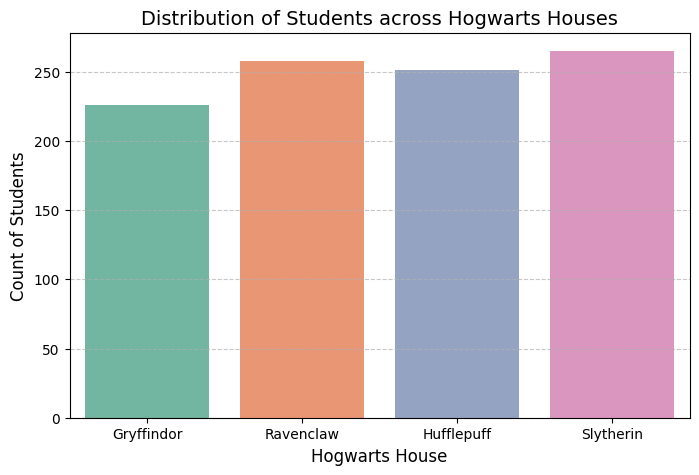

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='House', data=df, palette='Set2')
plt.title('Distribution of Students across Hogwarts Houses', fontsize=14)
plt.xlabel('Hogwarts House', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1881/1436117873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='House', y='Bravery', data=df, palette='Set1')


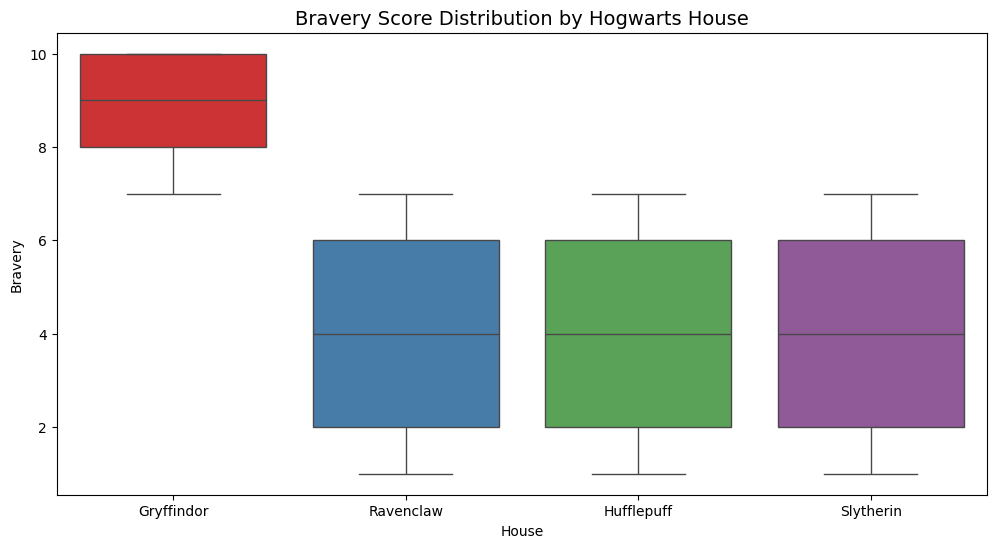

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='House', y='Bravery', data=df, palette='Set1')
plt.title('Bravery Score Distribution by Hogwarts House', fontsize=14)
plt.show()

# **=== Data Preprocessing & Feature Engineering ===**

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Blood Status'], drop_first=False)

In [ ]:
label_encoder = LabelEncoder()
df_encoded['House'] = label_encoder.fit_transform(df_encoded['House'])

In [ ]:
for index, house in enumerate(label_encoder.classes_):
    print(f"Encoded Value {index} -> {house}")

Encoded Value 0 -> Gryffindor
Encoded Value 1 -> Hufflepuff
Encoded Value 2 -> Ravenclaw
Encoded Value 3 -> Slytherin


In [ ]:
X = df_encoded.drop(columns=['House'])
y = df_encoded['House']

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1111, random_state=42, stratify=y_train_full)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 800
Validation set size: 100
Testing set size: 100


# **===Model Implementation ===**

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(4, activation='softmax')  # 4 classes for Gryffindor, Hufflepuff, Ravenclaw, Slytherin
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,364 (13.14 KB)

 Trainable params: 3,172 (12.39 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Define robust Early Stopping to mitigate excess runtime
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ***=== Training Phase ===***

In [ ]:
# Train model with tracking
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5913 - loss: 1.0126 - val_accuracy: 0.6000 - val_loss: 1.0697
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.4570 - val_accuracy: 0.9300 - val_loss: 0.7610
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9337 - loss: 0.2786 - val_accuracy: 0.9700 - val_loss: 0.5452
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9550 - loss: 0.2134 - val_accuracy: 0.9700 - val_loss: 0.3963
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9488 - loss: 0.1803 - val_accuracy: 0.9800 - val_loss: 0.2883
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9675 - loss: 0.1536 - val_accuracy: 0.9900 - val_loss: 0.2108
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9700 - loss: 0.1200 - val_accuracy: 0.9900 - val_loss: 0.1492
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9750 - loss: 0.1061 - val_accuracy: 1.0000 - 

# ***=== Performance Evaluation ===***

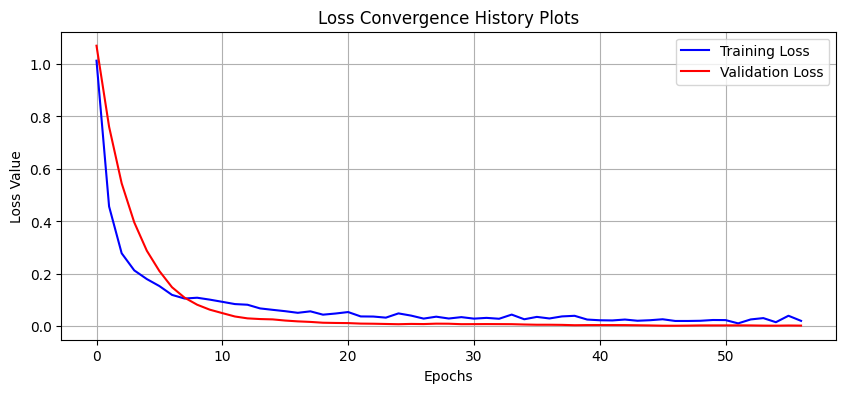

In [ ]:
# Plot Training Loss vs Validation Loss History Curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', color='b')
plt.plot(history.history['val_loss'], label='Validation Loss', color='r')
plt.title('Loss Convergence History Plots')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Generate Test Set Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [ ]:
# Summary Evaluation Metrics
print("\n=== Model Accuracy ===")
print(f"Test Set Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")


=== Model Accuracy ===
Test Set Accuracy Score: 99.00%


In [ ]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


=== Classification Report ===
              precision    recall  f1-score   support

  Gryffindor       1.00      1.00      1.00        23
  Hufflepuff       0.96      1.00      0.98        25
   Ravenclaw       1.00      0.96      0.98        26
   Slytherin       1.00      1.00      1.00        26

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



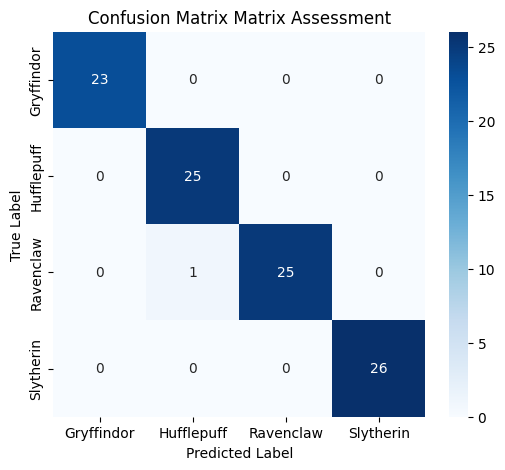

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix Matrix Assessment')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ***=== Final Prediction ===***

In [ ]:
# Provide a raw input array representing matching feature shapes
# Order must mirror scaled columns: Trait columns + Blood Status One-Hot encoded categories
# Columns are roughly: [Bravery, Intelligence, Loyalty, Ambition, Dark Arts, Quidditch, Dueling, Creativity, Blood_Half, Blood_Muggle, Blood_Pure]
student = np.array([[1, 8, 9, 6, 5, 4, 3, 9, 1, 0, 0]])

# Scale inputs correctly using pre-fit configurations
student_scaled = scaler.transform(student)

# Predict
predicted_probabilities = model.predict(student_scaled)
predicted_class = np.argmax(predicted_probabilities, axis=1)

# Invert mapped value back to actual string text
assigned_house = label_encoder.inverse_transform(predicted_class)
print(f"\nThe Sorting Hat puts the student in: **{assigned_house[0]}**")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

The Sorting Hat puts the student in: **Ravenclaw**


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
